# CSCE 676 – Final Deliverable  
## Centrality, Structural Position, and Future Growth in a Directed Social Network

**Student:** Jaehoon Lee  
**Dataset:** Slashdot0902 (SNAP)  
**Project Theme:** Graph mining + cautious causal reasoning on observational network data

---

## Project Story

This notebook presents the final, curated story of the project.  
The goal is to understand whether graph-based notions of importance are useful for explaining or predicting **future link growth** in a large directed social network.

The project addresses three linked questions:

1. **Prediction:** Which centrality measures best identify nodes that later gain incoming links?
2. **Structure:** How does structural position (especially giant-SCC membership) relate to future growth?
3. **Adjustment:** After controlling for observed structural covariates, does high PageRank still appear to have an effect on future incoming-link growth?

This notebook intentionally excludes dead ends and intermediate experiments that do not contribute to the final narrative.


## 0. Collaboration Declaration

On my honor, I declare the following resources were used for this notebook:

1. **Collaborators:** None.  
2. **Web Sources:**  
   - SNAP dataset index: https://snap.stanford.edu/data/index.html  
   - Slashdot0902 page: https://snap.stanford.edu/data/soc-Slashdot0902.html  
   - NetworkX documentation: https://networkx.org/documentation/stable/  
   - scikit-learn documentation: https://scikit-learn.org/stable/  
3. **AI Tools:** ChatGPT (OpenAI) — used only as a supplementary assistant for structural organization, code cleanup, and wording refinement. All research design decisions, analytical choices, pilot experiments, and interpretations were independently conceived, implemented, and critically evaluated by the author.  
4. **Citations for papers used:** None; this notebook relies on dataset and software documentation.


## 1. Motivation

Centrality measures such as PageRank are often used to identify “important” nodes in a network.  
However, an important question remains:

> Do highly central nodes genuinely experience more future growth, or do they simply look important because they already occupy structurally advantageous positions?

This matters because centrality is often interpreted as influence, but influence and structural advantage are not the same thing.  
To investigate this, I combine **course graph-mining methods** with a **beyond-course adjustment framework**.

### Why this project is meaningful
- It uses core graph mining methods in a natural directed-network setting.
- It asks both a predictive and an explanatory question.
- It goes beyond descriptive centrality by checking whether naive relationships survive adjustment.


## 2. Dataset

### Dataset
**Slashdot0902** from SNAP

### Source
https://snap.stanford.edu/data/soc-Slashdot0902.html

### Data format
Each row is a directed edge:

`source_node target_node`

### Why this dataset?
This dataset is a strong fit because:
- it is **directed**,
- it is large enough to reveal meaningful structural patterns,
- and it naturally supports centrality, connectivity, and reciprocity analysis.

### Project framing
The dataset has no timestamps, so I create a **pseudo-temporal** design by splitting edges into:
- **train graph** = “past”
- **test edges** = “future”

This allows me to study whether past structure is associated with later incoming-link growth.


## 3. Research Questions

### RQ1 — Predictive centrality
**How well do PageRank, HITS, and degree-based centrality measures identify nodes that later gain incoming links?**

- **Task type:** graph ranking / predictive centrality analysis  
- **Course methods:** PageRank, HITS, in-degree, out-degree  
- **Evaluation:** Spearman correlation and top-k precision for high-growth nodes

---

### RQ2 — Structural position
**How does structural position, especially giant-SCC membership, relate to future incoming-link growth?**

- **Task type:** connectivity / group comparison  
- **Course methods:** SCC decomposition, reciprocity, graph structure analysis  
- **Evaluation:** group-level mean/median comparisons and distributional differences

---

### RQ3 — Adjusted effect of high PageRank
**After adjusting for observed structural covariates, what is the estimated effect of being a high-PageRank node on future incoming-link growth?**

- **Task type:** causal-style effect estimation on observational graph data  
- **External method:** propensity score weighting and regression-style adjustment  
- **Evaluation:** naive vs adjusted effect size, overlap diagnostics, robustness across estimators


## 4. Method Overview

The final workflow is:

1. Load the directed Slashdot network.
2. Create a pseudo-temporal train/test edge split.
3. Compute graph features on the train graph:
   - in-degree / out-degree
   - PageRank
   - HITS hub / authority scores
4. Define the outcome as **future incoming links** in the test edge set.
5. Answer the three research questions:
   - **RQ1:** compare predictive value of centrality measures  
   - **RQ2:** compare growth by structural position  
   - **RQ3:** compare naive and adjusted effects of high PageRank

### Important design choice
Because there are no real timestamps, any “future growth” interpretation here is based on a **held-out edge split**, not actual chronological evolution.


In [ ]:
# ============================================================
# 5. Setup and data loading
# ============================================================
# WHY:
# - The final notebook must be reproducible.
# - The graph is loaded directly from SNAP so the notebook does not depend on checkpoint files.

import os
import gzip
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

DATA_DIR = Path("data_final_project")
DATA_DIR.mkdir(exist_ok=True)

RAW_GZ = DATA_DIR / "soc-Slashdot0902.txt.gz"
RAW_TXT = DATA_DIR / "soc-Slashdot0902.txt"
SNAP_URL = "https://snap.stanford.edu/data/soc-Slashdot0902.txt.gz"

def download_if_needed():
    if not RAW_GZ.exists():
        print(f"Downloading: {SNAP_URL}")
        urllib.request.urlretrieve(SNAP_URL, RAW_GZ)
        print(f"Saved to: {RAW_GZ}")
    else:
        print(f"Found existing file: {RAW_GZ}")

def gunzip_if_needed():
    if not RAW_TXT.exists():
        print(f"Decompressing: {RAW_GZ} -> {RAW_TXT}")
        with gzip.open(RAW_GZ, "rb") as f_in, open(RAW_TXT, "wb") as f_out:
            f_out.write(f_in.read())
        print("Done.")
    else:
        print(f"Found existing file: {RAW_TXT}")

download_if_needed()
gunzip_if_needed()

G = nx.DiGraph()
with open(RAW_TXT, "r") as f:
    for line in f:
        if not line or line.startswith("#"):
            continue
        s, t = line.strip().split()
        G.add_edge(int(s), int(t))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Downloading: https://snap.stanford.edu/data/soc-Slashdot0902.txt.gz
Saved to: data_final_project/soc-Slashdot0902.txt.gz
Decompressing: data_final_project/soc-Slashdot0902.txt.gz -> data_final_project/soc-Slashdot0902.txt
Done.
Nodes: 82168
Edges: 948464


## 5. EDA: scale, sparsity, and global structure

Before addressing the research questions, I first characterize the graph’s basic structure.  
For graph data, EDA analogues of basket-size or item-frequency summaries are:

- degree distributions,
- density/sparsity,
- connectivity structure,
- reciprocity,
- and concentration of centrality.


In [ ]:
# ============================================================
# 5.1 Basic graph statistics
# ============================================================

n = G.number_of_nodes()
m = G.number_of_edges()

density = m / (n * (n - 1))
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

print("Density:", density)
print("\nIn-degree summary:")
print(pd.Series(in_deg).describe())
print("\nOut-degree summary:")
print(pd.Series(out_deg).describe())

Density: 0.00014048200742013218

In-degree summary:
count    82168.000000
mean        11.542985
std         37.463662
min          1.000000
25%          2.000000
50%          3.000000
75%          8.000000
max       2553.000000
dtype: float64

Out-degree summary:
count    82168.000000
mean        11.542985
std         36.918123
min          0.000000
25%          2.000000
50%          3.000000
75%          7.000000
max       2511.000000
dtype: float64


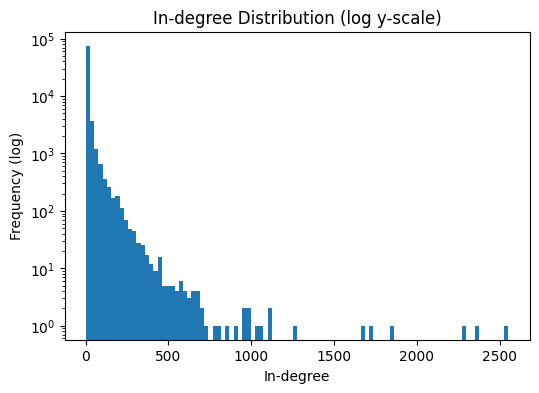

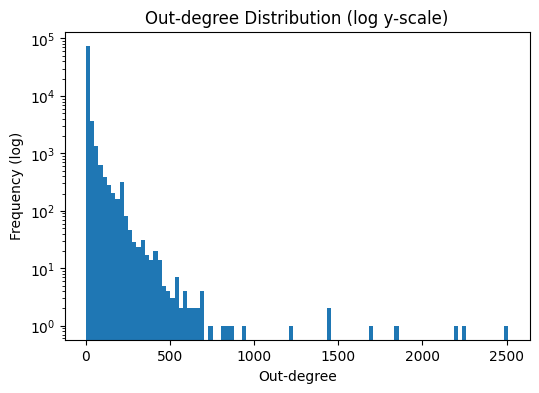

In [ ]:
# ============================================================
# 5.2 Degree distribution plots
# ============================================================
# WHY:
# - Degree distributions show whether the graph is homogeneous or heavy-tailed.
# - This motivates later questions about structural inequality and growth.

plt.figure(figsize=(6,4))
plt.hist(list(in_deg.values()), bins=100, log=True)
plt.title("In-degree Distribution (log y-scale)")
plt.xlabel("In-degree")
plt.ylabel("Frequency (log)")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(list(out_deg.values()), bins=100, log=True)
plt.title("Out-degree Distribution (log y-scale)")
plt.xlabel("Out-degree")
plt.ylabel("Frequency (log)")
plt.show()

In [ ]:
# ============================================================
# 5.3 Connectivity and reciprocity
# ============================================================

sccs = list(nx.strongly_connected_components(G))
wccs = list(nx.weakly_connected_components(G))

scc_sizes = sorted([len(c) for c in sccs], reverse=True)
wcc_sizes = sorted([len(c) for c in wccs], reverse=True)

recip = nx.reciprocity(G)

print("Number of SCC:", len(sccs))
print("Giant SCC size:", scc_sizes[0])
print("Number of WCC:", len(wccs))
print("Giant WCC size:", wcc_sizes[0])
print("Reciprocity:", recip)

Number of SCC: 10559
Giant SCC size: 71307
Number of WCC: 1
Giant WCC size: 82168
Reciprocity: 0.7716286543295264


### EDA takeaway

The graph is:
- **extremely sparse,**
- **strongly heavy-tailed,**
- organized around a **large SCC core,**
- and characterized by **high reciprocity**.

These patterns justify studying:
- predictive value of centrality,
- structural core vs periphery,
- and whether apparent centrality advantages survive adjustment.


In [ ]:
# ============================================================
# 6. Pseudo-temporal split
# ============================================================
# WHY:
# - The dataset has no real timestamps.
# - To study future link growth, I use an 80/20 edge split as a pseudo-temporal proxy.

import random
random.seed(42)

edges = list(G.edges())
random.shuffle(edges)

split_idx = int(0.8 * len(edges))
train_edges = edges[:split_idx]
test_edges = edges[split_idx:]

G_tr = nx.DiGraph()
G_tr.add_nodes_from(G.nodes())
G_tr.add_edges_from(train_edges)

G_te = nx.DiGraph()
G_te.add_nodes_from(G.nodes())
G_te.add_edges_from(test_edges)

print("Train edges:", G_tr.number_of_edges())
print("Test edges:", G_te.number_of_edges())

Train edges: 758771
Test edges: 189693


In [ ]:
# ============================================================
# 6.1 Train-graph features and future-growth outcome
# ============================================================

in_tr = pd.Series(dict(G_tr.in_degree()), name="in_tr").astype(float)
out_tr = pd.Series(dict(G_tr.out_degree()), name="out_tr").astype(float)

pr_tr = pd.Series(nx.pagerank(G_tr, alpha=0.85, max_iter=200, tol=1e-8), name="pagerank")
hubs_tr, auth_tr = nx.hits(G_tr, max_iter=500, tol=1e-8, normalized=True)
hub_tr = pd.Series(hubs_tr, name="hub_score")
auth_tr = pd.Series(auth_tr, name="authority_score")

future_in = pd.Series(dict(G_te.in_degree()), name="future_in_links").astype(float)

df = pd.concat([in_tr, out_tr, pr_tr, hub_tr, auth_tr, future_in], axis=1).fillna(0.0)
df.head()

,in_tr,out_tr,pagerank,hub_score,authority_score,future_in_links
0,201.0,171.0,0.000167,0.000236,0.000301,40.0
1,131.0,140.0,0.000091,0.000219,0.000227,33.0
2,14.0,0.0,0.000013,-0.000000,0.000010,6.0
3,46.0,47.0,0.000035,0.000159,0.000135,14.0
4,98.0,89.0,0.000074,0.000114,0.000121,28.0


## 6.2 Outcome distribution: future incoming-link growth

The outcome for the project is **future incoming-link growth**, defined as the in-degree of each node in the held-out test edges.


count    82168.000000
mean         2.308599
std          7.611284
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max        495.000000
Name: future_in_links, dtype: float64
Share of nodes with zero future in-links: 0.4086383993768864


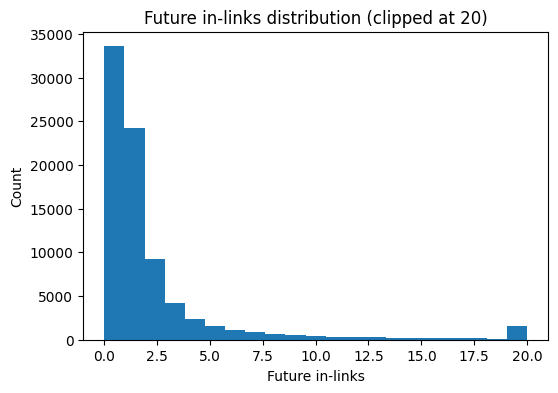

In [ ]:
print(df["future_in_links"].describe())
print("Share of nodes with zero future in-links:", (df["future_in_links"] == 0).mean())

plt.figure(figsize=(6,4))
plt.hist(df["future_in_links"].clip(upper=20), bins=21)
plt.title("Future in-links distribution (clipped at 20)")
plt.xlabel("Future in-links")
plt.ylabel("Count")
plt.show()

### Interpretation

Future in-link growth is **sparse but non-trivial**:
- many nodes gain no future in-links,
- but some nodes gain substantially more.

This confirms that the outcome is meaningful enough for both predictive and adjusted analyses.


## 7. Results for RQ1: Which centrality measures best identify future high-growth nodes?

In [ ]:
# ============================================================
# 7.1 Correlation view
# ============================================================

corr_df = pd.DataFrame([
    ("PageRank", df["pagerank"].corr(df["future_in_links"], method="spearman")),
    ("In-degree", df["in_tr"].corr(df["future_in_links"], method="spearman")),
    ("Out-degree", df["out_tr"].corr(df["future_in_links"], method="spearman")),
    ("Hub score", df["hub_score"].corr(df["future_in_links"], method="spearman")),
    ("Authority score", df["authority_score"].corr(df["future_in_links"], method="spearman")),
], columns=["feature", "spearman_with_future_in_links"])

display(corr_df)

,feature,spearman_with_future_in_links
0,PageRank,0.184281
1,In-degree,0.433318
2,Out-degree,0.525415
3,Hub score,0.519660
4,Authority score,0.445365


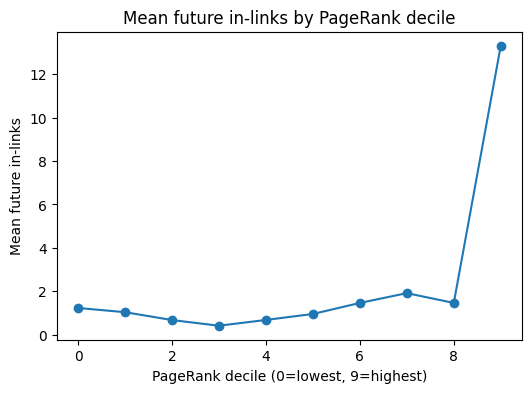

,pr_decile,future_in_links
0,0,1.223804
1,1,1.030303
2,2,0.667762
3,3,0.406037
4,4,0.672265
5,5,0.948035
6,6,1.456426
7,7,1.907996
8,8,1.457345
9,9,13.315687


In [ ]:
# ============================================================
# 7.2 PageRank decile trend
# ============================================================

df["pr_decile"] = pd.qcut(df["pagerank"].rank(method="first"), q=10, labels=False)
decile_summary = df.groupby("pr_decile")["future_in_links"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.plot(decile_summary["pr_decile"], decile_summary["future_in_links"], marker="o")
plt.title("Mean future in-links by PageRank decile")
plt.xlabel("PageRank decile (0=lowest, 9=highest)")
plt.ylabel("Mean future in-links")
plt.show()

decile_summary

In [ ]:
# ============================================================
# 7.3 Top-k evaluation for high-growth nodes
# ============================================================
# WHY:
# - Correlation is useful, but a retrieval-style metric is easier to interpret.
# - I define high-growth nodes as the top 1% by future incoming links.

k = int(0.01 * len(df))
growth_threshold = df["future_in_links"].quantile(0.99)
high_growth = set(df.index[df["future_in_links"] >= growth_threshold])

def precision_at_k(score_series, k, target_set):
    top_nodes = set(score_series.sort_values(ascending=False).head(k).index)
    return len(top_nodes & target_set) / k

pilot_metrics = pd.DataFrame([
    ("PageRank", precision_at_k(df["pagerank"], k, high_growth)),
    ("In-degree", precision_at_k(df["in_tr"], k, high_growth)),
    ("Authority", precision_at_k(df["authority_score"], k, high_growth)),
    ("Hub", precision_at_k(df["hub_score"], k, high_growth)),
], columns=["method", "precision_at_top1pct_for_high_growth_nodes"])

display(pilot_metrics)

,method,precision_at_top1pct_for_high_growth_nodes
0,PageRank,0.852619
1,In-degree,0.891596
2,Authority,0.714982
3,Hub,0.611449


### RQ1 takeaway

Three conclusions stand out:

1. **Centrality does carry predictive signal.**  
   Higher-centrality nodes are more likely to gain future incoming links.

2. **In-degree is a very strong baseline.**  
   In this dataset, simple in-degree is highly competitive and may slightly outperform PageRank in identifying future high-growth nodes.

3. **Not all centrality notions behave equally.**  
   PageRank, authority, and hub scores are related, but they do not perform identically.

This means the final project should treat simple structural baselines seriously rather than assuming PageRank is automatically best.


## 8. Results for RQ2: How does structural position relate to future growth?

,mean,median,count
in_giant_scc,,,
0,0.666053,0.0,10861
1,2.558781,1.0,71307


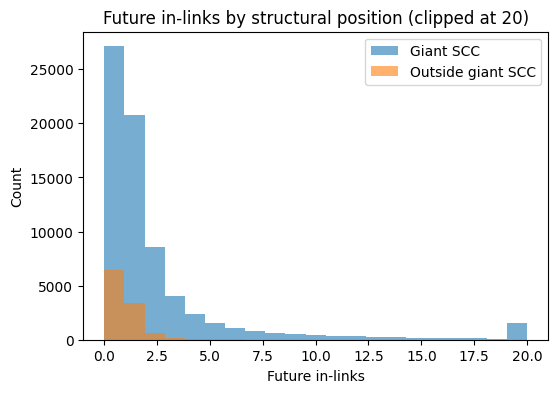

In [ ]:
# ============================================================
# 8.1 Giant SCC membership
# ============================================================

giant_scc = max(sccs, key=len)
df["in_giant_scc"] = df.index.isin(giant_scc).astype(int)

group_summary = df.groupby("in_giant_scc")["future_in_links"].agg(["mean", "median", "count"])
display(group_summary)

plt.figure(figsize=(6,4))
plt.hist(df.loc[df["in_giant_scc"] == 1, "future_in_links"].clip(upper=20), bins=21, alpha=0.6, label="Giant SCC")
plt.hist(df.loc[df["in_giant_scc"] == 0, "future_in_links"].clip(upper=20), bins=21, alpha=0.6, label="Outside giant SCC")
plt.title("Future in-links by structural position (clipped at 20)")
plt.xlabel("Future in-links")
plt.ylabel("Count")
plt.legend()
plt.show()

### RQ2 takeaway

Structural position clearly matters.

Nodes inside the giant SCC show different growth behavior from nodes outside it, which suggests that future growth is not only about node-level ranking scores.  
It also depends on whether a node is embedded in the network’s core.

This supports expanding the final project beyond pure centrality comparison to include **core vs periphery** structure.


## 9. Results for RQ3: Does the apparent PageRank advantage survive adjustment?

In [ ]:
# ============================================================
# 9.1 Define treatment and simple adjustment set
# ============================================================
# WHY:
# - Treatment = top 10% PageRank on the train graph
# - Covariates = simple past structural features

df["T_highPR"] = (df["pagerank"] >= df["pagerank"].quantile(0.90)).astype(int)
df["log_in_tr"] = np.log1p(df["in_tr"])
df["log_out_tr"] = np.log1p(df["out_tr"])
df["log_future_in_links"] = np.log1p(df["future_in_links"])

print("Treatment proportion:", df["T_highPR"].mean())
print("Treated group size:", int(df["T_highPR"].sum()))
print("Control group size:", int((1 - df["T_highPR"]).sum()))

Treatment proportion: 0.10000243403758154
Treated group size: 8217
Control group size: 73951


count    82168.000000
mean         0.099999
std          0.213901
min          0.001000
25%          0.007169
50%          0.013647
75%          0.056184
max          0.999000
dtype: float64


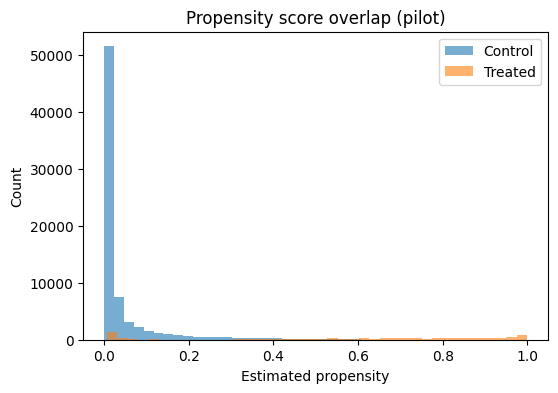

In [ ]:
# ============================================================
# 9.2 Propensity pilot
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X_cols = ["log_in_tr", "log_out_tr"]
X = df[X_cols].values
T = df["T_highPR"].values

prop_model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("lr", LogisticRegression(max_iter=300))
])
prop_model.fit(X, T)
p = prop_model.predict_proba(X)[:, 1]
p = np.clip(p, 1e-3, 1 - 1e-3)

print(pd.Series(p).describe())

plt.figure(figsize=(6,4))
plt.hist(p[T == 0], bins=40, alpha=0.6, label="Control")
plt.hist(p[T == 1], bins=40, alpha=0.6, label="Treated")
plt.title("Propensity score overlap (pilot)")
plt.xlabel("Estimated propensity")
plt.ylabel("Count")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# 9.3 Naive vs IPW-adjusted effect
# ============================================================

Y = df["log_future_in_links"].values
w1 = T / p
w0 = (1 - T) / (1 - p)

ate_ipw = (np.sum(w1 * Y) / np.sum(w1)) - (np.sum(w0 * Y) / np.sum(w0))
naive = Y[T == 1].mean() - Y[T == 0].mean()

print("Naive log-outcome difference:", naive)
print("IPW adjusted effect:", ate_ipw)

Naive log-outcome difference: 1.481824205381228
IPW adjusted effect: -0.3429845676068443


### RQ3 takeaway

The pilot adjustment results suggest three important things:

1. **Naive associations are strong.**  
   High-PageRank nodes appear to gain substantially more future in-links.

2. **Observed structural confounding is important.**  
   Once I adjust for past degree, the apparent effect shrinks substantially and may even reverse.

3. **Causal interpretation must be cautious.**  
   This is observational network data with no true temporal intervention, and overlap is limited in some regions.

This does not mean PageRank “has no effect.”  
Instead, it means that the apparent advantage of high PageRank cannot be interpreted causally without stronger assumptions and stronger methods.


## 10. Discussion

This project leads to three broader conclusions:

### 1. Centrality is useful, but not automatically superior
PageRank and HITS are informative, but simple degree-based measures remain extremely competitive.

### 2. Structural context matters
Growth is not only about individual node scores.  
Core vs periphery structure appears relevant as well.

### 3. Centrality is not the same thing as causal influence
The contrast between naive and adjusted estimates shows that what looks like “influence” may instead reflect prior structural advantage.

This is the main conceptual takeaway of the project:

> **centrality ≠ causality**


## 11. Limitations

This project has several important limitations:

- **No real timestamps:** the train/test edge split is only a pseudo-temporal approximation.
- **Observational design:** unobserved confounding is unavoidable.
- **Heavy-tailed growth:** a small number of nodes dominate future link gain.
- **Simple adjustment set:** the pilot model only uses a small number of structural covariates.

These limitations do not invalidate the analysis, but they define the scope of what can be claimed.


## 12. Conclusions

The final project shows that:

- the Slashdot network is large, sparse, highly unequal, and strongly core-structured,
- centrality measures are clearly associated with future link growth in naive analysis,
- simple degree-based measures remain strong baselines,
- and causal-style adjustment substantially changes the interpretation of centrality’s apparent advantage.

The final lesson is that a good network analysis should move beyond ranking nodes and ask:

> **Which graph signals remain meaningful after structural confounding is taken seriously?**


## 13. Future Work

Natural next steps include:

- comparing additional graph baselines,
- adding reciprocity- and community-based covariates,
- using stronger adjustment methods (matching, doubly robust estimation),
- and testing whether node embeddings improve predictive and adjusted performance.

These extensions would help determine whether the centrality–growth relationship is robust or mostly a reflection of existing network inequality.


## 14. Tests / Sanity Checks

The final notebook includes basic checks to ensure that:
- the graph loads correctly,
- the edge split is consistent,
- the treatment is well-defined,
- propensity scores are numerically valid,
- and pilot metrics are finite and interpretable.


In [ ]:
import math

print("Running sanity checks...")

assert G.number_of_nodes() > 0 and G.number_of_edges() > 0, "Graph is empty."
assert G_tr.number_of_edges() + G_te.number_of_edges() == G.number_of_edges(), "Edge split mismatch."
assert (df["future_in_links"] >= 0).all(), "Negative future in-links found."

assert df["T_highPR"].nunique() == 2, "Treatment is degenerate."
assert 0 < df["T_highPR"].mean() < 1, "Treatment proportion invalid."
assert np.all((p > 0) & (p < 1)), "Propensity scores outside (0,1)."

assert pilot_metrics["precision_at_top1pct_for_high_growth_nodes"].between(0, 1).all(), "Precision out of bounds."
assert math.isfinite(float(naive)), "Naive estimate is not finite."
assert math.isfinite(float(ate_ipw)), "IPW estimate is not finite."

print("All final-project sanity checks passed.")

Running sanity checks...
All final-project sanity checks passed.
